# Thailand (full-nodal, PCM)

PREP-SHOT in **production-cost-model (PCM) mode** on the full Thai grid: every one of the 472 buses stays a separate PREP-SHOT zone, every thermal unit is its own tech, the 615 transmission lines carry their full electrical parameters (reactance, susceptance, thermal limit), and the 8760-hour 2023 load profile is dispatched window-by-window via [prepshot.pcm](../../prepshot/pcm.py).

**No spatial aggregation.** Where the [Thailand](Thailand.ipynb) example collapses the country to a single zone, this one keeps every node and every electrical line. It's the highest-fidelity PREP-SHOT scenario shipped.

**What you'll do here:**

1. Convert an upstream nodal PCM dataset to PREP-SHOT's long-format CSV schema.
2. Inspect the converted inputs.
3. Run the PCM rolling-horizon driver on a 24-hour window.


## 1. Source data

We start from the Thai PCM dataset shipped at `production-cost-model-main/`. Headline counts:

| Item | Count | Source file |
|------|------:|-------------|
| Buses (= PREP-SHOT zones) | 472 | `load_demand.csv` columns |
| Transmission lines | 615 | `grid_topology.csv` |
| Thermal units | 168 | `generators.xlsx` `Thermal` sheet |
| VRE plants (solar + wind) | 30 | `generators.xlsx` `Renewable` sheet |
| Hydro stations | 14 | `hydropower.xlsx` `Sheet2` |
| Hours | 8760 (full year 2023) | `load_demand.csv`, `capacity_factor.csv` |

Hydro inflow only covers 2016–2019; we use **2019** re-stamped onto 2023 hours.

In [1]:
import pathlib
import pandas as pd

# Adjust this path to wherever the upstream PCM dataset lives.
SRC = pathlib.Path('/Users/energy/01-doing/PREP-SHOT-tutorial/production-cost-model-main/input')

# Output goes into examples/thailand_pcm/input/
this_dir = pathlib.Path.cwd()
while not (this_dir / 'config.json').exists() or not this_dir.name == 'thailand_pcm':
    if this_dir == this_dir.parent:
        raise RuntimeError(
            'Run this notebook from inside examples/thailand_pcm/ or '
            'with cwd somewhere under it.'
        )
    this_dir = this_dir.parent
OUT = this_dir / 'input'
OUT.mkdir(parents=True, exist_ok=True)
print(f'Source: {SRC}')
print(f'Output: {OUT}')

Source: /Users/energy/01-doing/PREP-SHOT-tutorial/production-cost-model-main/input
Output: /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/examples/thailand_pcm/input


## 2. Conversion: zones, techs, fleet

Each bus becomes a PREP-SHOT zone. Each plant (thermal unit, VRE plant, hydro station) becomes a separate tech — fleet-level aggregation only happens via the `tech_registry.csv`'s `carrier` column.

In [2]:
demand = pd.read_csv(SRC / 'load_demand.csv')
zones = sorted(c for c in demand.columns if c.startswith('bus'))
print(f'  zones: {len(zones)} (e.g., {zones[:3]} ... {zones[-3:]})')

tt = pd.read_excel(SRC / 'generators.xlsx', 'Thermal')
rt = pd.read_excel(SRC / 'generators.xlsx', 'Renewable')
ht = pd.read_excel(SRC / 'hydropower.xlsx', 'Sheet2')
thermal_names = list(tt['name'].astype(str))
renew_names = list(rt['name'].astype(str))
hydro_names = list(ht['short_name'].fillna(ht['name']).astype(str))
print(f'  thermal techs:   {len(thermal_names)}')
print(f'  renewable techs: {len(renew_names)}')
print(f'  hydro techs:     {len(hydro_names)}')

tech_registry = []
for n in thermal_names:
    carrier = tt.loc[tt['name'] == n, 'fuel_type'].iloc[0]
    tech_registry.append({'tech': n, 'name': n, 'carrier': carrier, 'is_storage': False})
for n in renew_names:
    carrier = rt.loc[rt['name'] == n, 'tech'].iloc[0]
    tech_registry.append({'tech': n, 'name': n, 'carrier': carrier, 'is_storage': False})
for n in hydro_names:
    tech_registry.append({'tech': n, 'name': n, 'carrier': 'hydro', 'is_storage': False})
pd.DataFrame(tech_registry).to_csv(OUT / 'tech_registry.csv', index=False)
print(f'  total tech registry: {len(tech_registry)} rows')

  zones: 472 (e.g., ['bus1', 'bus10', 'bus100'] ... ['bus97', 'bus98', 'bus99'])
  thermal techs:   168
  renewable techs: 30
  hydro techs:     14
  total tech registry: 212 rows


In [3]:
YEAR = 2023
fleet_rows = []
for _, r in tt.iterrows():
    fleet_rows.append({'tech': r['name'], 'zone': r['node'], 'commission_year': YEAR,
                       'unit': 'MW', 'capacity': float(r['max_capacity'])})
for _, r in rt.iterrows():
    fleet_rows.append({'tech': r['name'], 'zone': r['node_id'], 'commission_year': YEAR,
                       'unit': 'MW', 'capacity': float(r['p_nom'])})
for n, (_, r) in zip(hydro_names, ht.iterrows()):
    fleet_rows.append({'tech': n, 'zone': r['node_id'], 'commission_year': YEAR,
                       'unit': 'MW', 'capacity': float(r['N(MW)'])})
fleet = pd.DataFrame(fleet_rows)
fleet.to_csv(OUT / 'tech_existing.csv', index=False)

# Cap-source CSV consumed by `prepshot.pcm --cap-source`.
fleet.rename(columns={'commission_year': 'year'})[
    ['zone', 'tech', 'year', 'capacity']
].to_csv(OUT / 'capacity_pcm.csv', index=False)
fleet.head()

,tech,zone,commission_year,unit,capacity
0,BLCP-T,bus69,2023,MW,1347.0
1,BPK-C1,bus328,2023,MW,1386.0
2,BPK-C5,bus328,2023,MW,710.0
3,BPK-T,bus328,2023,MW,1152.0
4,CHN-C1,bus40,2023,MW,710.0


## 3. Load + VRE capacity factors + hydro inflow

Three time-varying tables. The load alone is **4.1 M rows** in long format (472 buses × 8760 hours).

In [4]:
ld = demand.copy()
ts_col = ld.columns[0]
ld['ts'] = pd.to_datetime(ld[ts_col])
ld['hour'] = ((ld['ts'] - ld['ts'].iloc[0]).dt.total_seconds() // 3600).astype(int) + 1
ld = ld.drop(columns=[ts_col, 'ts'])
long_load = ld.melt(id_vars='hour', var_name='zone', value_name='value')
long_load['year'] = YEAR
long_load['month'] = 1
long_load['unit'] = 'MW'
long_load[['zone','year','month','hour','unit','value']].to_csv(OUT / 'demand.csv', index=False)
print(f'demand.csv: {len(long_load):,} rows')

demand.csv: 4,134,720 rows


In [5]:
cf = pd.read_csv(SRC / 'capacity_factor.csv')
cf['ts'] = pd.to_datetime(cf['time'])
cf['hour'] = ((cf['ts'] - cf['ts'].iloc[0]).dt.total_seconds() // 3600).astype(int) + 1
cf = cf.drop(columns=['time', 'ts'])
rt_idx = rt.set_index('name')
cf_rows = []
for plant in [c for c in cf.columns if c != 'hour']:
    if plant not in rt_idx.index:
        continue
    zone = str(rt_idx.loc[plant, 'node_id'])
    for _, r in cf.iterrows():
        cf_rows.append({'tech': plant, 'zone': zone, 'year': YEAR,
                        'month': 1, 'hour': int(r['hour']),
                        'unit': 'fraction', 'value': float(r[plant])})
pd.DataFrame(cf_rows).to_csv(OUT / 'tech_max_gen_profile.csv', index=False)
print(f'tech_max_gen_profile.csv: {len(cf_rows):,} rows')

tech_max_gen_profile.csv: 262,800 rows


In [6]:
# Inflow proxy: source covers 2016-2019, target year is 2023; use 2019.
inf = pd.read_csv(SRC / 'inflow.csv')
inf['ts'] = pd.to_datetime(inf['time'])
inf = inf[inf['ts'].dt.year == 2019].copy().reset_index(drop=True)
inf['hour'] = (inf.index + 1).astype(int)
inflow_rows = []
for i, name in enumerate(hydro_names, start=1):
    col = str(i)
    if col not in inf.columns:
        continue
    for _, r in inf.iterrows():
        inflow_rows.append({'tech': name, 'year': YEAR, 'month': 1,
                            'hour': int(r['hour']), 'unit': 'm3/s',
                            'value': float(r[col])})
pd.DataFrame(inflow_rows).to_csv(OUT / 'reservoir_inflow.csv', index=False)
print(f'reservoir_inflow.csv: {len(inflow_rows):,} rows')

reservoir_inflow.csv: 122,640 rows


## 4. Transmission topology

615 directed lines from `grid_topology.csv` become (zone1, zone2) pairs in `transmission_existing.csv`. Susceptance comes from the `user_susceptance` column when set, else falls back to `2 × cap_MW / rad` (the same heuristic the SE Asia example uses).

**Sentinel handling:** the source uses `user_line_cap = -1` to mean "use the computed thermal limit"; we treat that explicitly rather than via `or`, which would select `-1` because it's truthy in Python.

In [7]:
gt = pd.read_csv(SRC / 'grid_topology.csv')
trans_rows = []
susc_rows = []
seen_pairs = set()
for _, r in gt.iterrows():
    s, k = str(r['source']), str(r['sink'])
    ulc = float(r.get('user_line_cap', 0) or 0)
    cap = ulc if ulc > 0 else float(r.get('thermal_limit') or 0)
    if cap <= 0:
        continue
    trans_rows.append({'zone1': s, 'zone2': k, 'commission_year': YEAR,
                       'unit': 'MW', 'value': cap})
    trans_rows.append({'zone1': k, 'zone2': s, 'commission_year': YEAR,
                       'unit': 'MW', 'value': cap})
    a, b = sorted([s, k])
    if (a, b) in seen_pairs:
        continue
    seen_pairs.add((a, b))
    b_pu = float(r.get('user_susceptance') or 0)
    if b_pu <= 0:
        b_pu = max(2.0 * cap, 1000.0)
    susc_rows.append({'zone1': a, 'zone2': b, 'unit': 'MW/rad', 'value': b_pu})
pd.DataFrame(trans_rows).to_csv(OUT / 'transmission_existing.csv', index=False)
pd.DataFrame(susc_rows).to_csv(OUT / 'transmission_susceptance.csv', index=False)
print(f'transmission_existing.csv: {len(trans_rows)} rows, '
      f'transmission_susceptance.csv: {len(susc_rows)} pairs')

transmission_existing.csv: 1230 rows, transmission_susceptance.csv: 615 pairs


## 5. Per-station hydropower

PREP-SHOT models hydropower at the plant level with cascade physics (water balance, head iteration, downstream-feeds-upstream water-delay). The Thai dataset has 14 stations with full reservoir parameters: head, coefficient, V_max/min, outflow_max/min, downstream link, delay hours.

We ship the cascade as `reservoir_water_delay_time.csv`, the static parameters as their own CSVs, and the time-varying storage bounds as `reservoir_storage_min.csv` / `reservoir_storage_max.csv` (constant across hours since the source has no time variation). Initial / final storage levels default to 50 % of `V_max` — the same convention the [SoutheastAsia](SoutheastAsia.ipynb) example settled on for stable rolling-horizon.

In [8]:
pd.DataFrame({'tech': hydro_names, 'unit': 'm', 'head': ht['head'].astype(float).values}).to_csv(
    OUT / 'reservoir_head.csv', index=False)
pd.DataFrame({'tech': hydro_names, 'unit': 'MW/(m*m3/s)',
              'coefficient': ht['coeff'].astype(float).values}).to_csv(
    OUT / 'reservoir_coefficient.csv', index=False)
pd.DataFrame({'tech': hydro_names, 'unit': 'MW',
              'capacity_max': ht['N_max'].astype(float).values}).to_csv(
    OUT / 'reservoir_capacity_max.csv', index=False)
pd.DataFrame({'tech': hydro_names, 'unit': 'MW',
              'capacity_min': ht['N_min'].fillna(0).astype(float).values}).to_csv(
    OUT / 'reservoir_capacity_min.csv', index=False)
pd.DataFrame({'tech': hydro_names, 'unit': 'm3/s',
              'generation_flow_max': ht['GQ_max'].astype(float).values}).to_csv(
    OUT / 'reservoir_generation_flow_max.csv', index=False)
pd.DataFrame({'tech': hydro_names, 'unit': 'm3/s',
              'outflow_max': ht['outflow_max'].astype(float).values}).to_csv(
    OUT / 'reservoir_outflow_max.csv', index=False)
pd.DataFrame({'tech': hydro_names, 'unit': 'm3/s',
              'outflow_min': ht['outflow_min'].fillna(0).astype(float).values}).to_csv(
    OUT / 'reservoir_outflow_min.csv', index=False)

init_storage = (ht['V_max'].astype(float) * 0.5).values
pd.DataFrame({'tech': hydro_names, 'unit': 'm3', 'value': init_storage}).to_csv(
    OUT / 'reservoir_initial_storage_level.csv', index=False)
pd.DataFrame({'tech': hydro_names, 'unit': 'm3', 'value': init_storage}).to_csv(
    OUT / 'reservoir_final_storage_level.csv', index=False)
pd.DataFrame({'tech': hydro_names,
              'zone': [str(z) for z in ht['node_id'].values]}).to_csv(
    OUT / 'reservoir_zone.csv', index=False)

# Cascade topology (downstream + delay).
wdt_rows = []
for n, ds, dly in zip(hydro_names, ht['downstream'].fillna('').values,
                      ht['delay_hours'].fillna(0).values):
    if not str(ds).strip() or str(ds).lower() == 'nan':
        continue
    try:
        ds_int = int(float(ds))
    except (TypeError, ValueError):
        continue
    match = ht[ht['stcd'].astype(int) == ds_int]
    if match.empty:
        continue
    downstream_name = str(match['short_name'].iloc[0] or match['name'].iloc[0])
    wdt_rows.append({'upstream_tech': n, 'downstream_tech': downstream_name,
                     'delay': int(float(dly))})
pd.DataFrame(wdt_rows or [], columns=['upstream_tech','downstream_tech','delay']).to_csv(
    OUT / 'reservoir_water_delay_time.csv', index=False)
print(f'cascade pairs: {len(wdt_rows)}')

cascade pairs: 0


## 6. Input visualisations

The model is too large for the LP build to complete on the current
codebase (see Section 9), so we don't have a solved baseline to
plot from. The input dataset itself, though, has plenty worth
inspecting -- bus geography, the cascade topology, the
fleet-by-carrier mix, and the load shape. These are the same
diagnostics you'd reach for before any production run.


### 6.1 Bus locations and demand

Every PREP-SHOT zone in this scenario is one bus on the Thai grid.
We can plot all 472 of them on a map and size each marker by its
peak hourly demand.


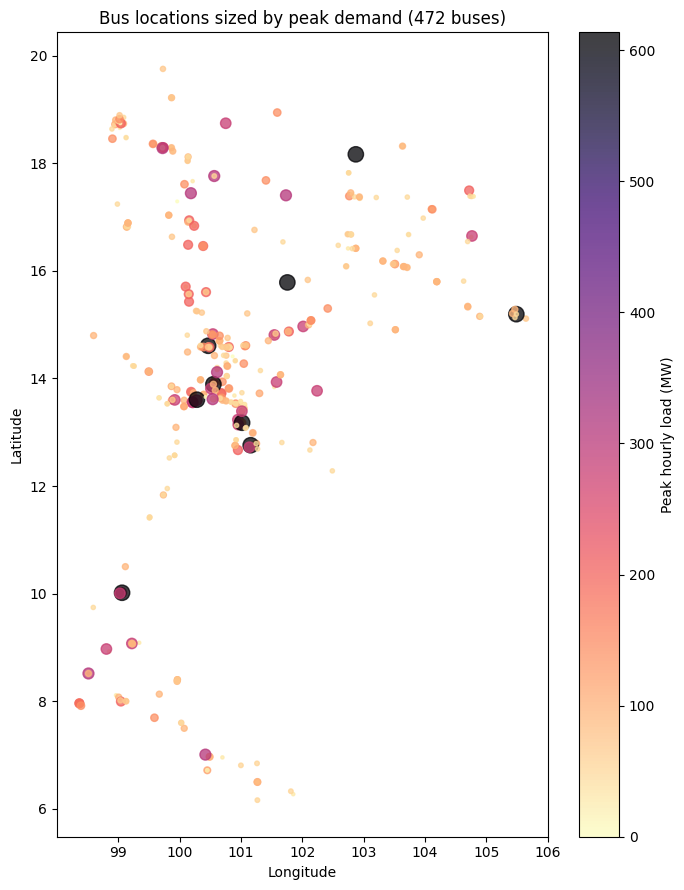

In [9]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Bus coordinates: take the first occurrence of each bus across the
# source/sink columns of grid_topology.csv, since each bus is
# referenced many times.
bus_lonlat = {}
for _, r in gt.iterrows():
    bus_lonlat.setdefault(str(r['source']), (r['source_lon'], r['source_lat']))
    bus_lonlat.setdefault(str(r['sink']),   (r['sink_lon'],   r['sink_lat']))

# Peak demand per bus from the long-format load table built earlier.
peak = (
    long_load.groupby('zone')['value'].max().rename('peak_mw').reset_index()
)
peak['lon'] = peak['zone'].map(lambda z: bus_lonlat.get(z, (np.nan, np.nan))[0])
peak['lat'] = peak['zone'].map(lambda z: bus_lonlat.get(z, (np.nan, np.nan))[1])
peak = peak.dropna(subset=['lon', 'lat'])

fig, ax = plt.subplots(figsize=(7, 9))
sc = ax.scatter(
    peak['lon'], peak['lat'],
    s=np.clip(peak['peak_mw'] / 5, 4, 200),
    c=peak['peak_mw'], cmap='magma_r', alpha=0.75,
)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Bus locations sized by peak demand ({len(peak)} buses)')
fig.colorbar(sc, ax=ax, label='Peak hourly load (MW)')
plt.tight_layout(); plt.show()


### 6.2 Transmission network

615 lines, three voltage classes (115 / 230 / 500 kV). Visualise
the skeleton on the same map -- line width proportional to thermal
capacity.


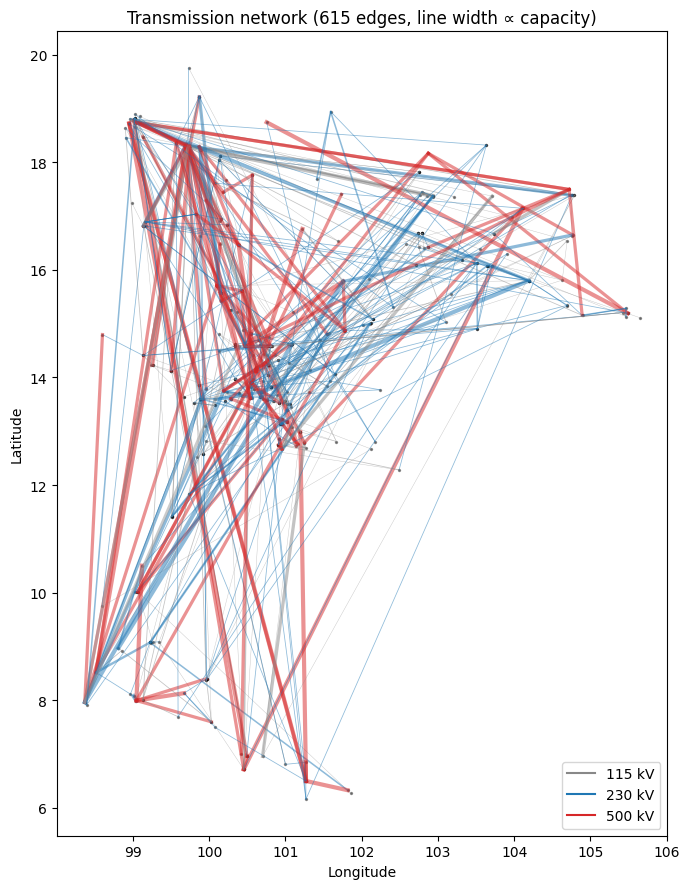

In [10]:
fig, ax = plt.subplots(figsize=(7, 9))
ax.scatter(peak['lon'], peak['lat'], s=2, color='black', alpha=0.4)
for _, r in gt.iterrows():
    s, k = str(r['source']), str(r['sink'])
    if s not in bus_lonlat or k not in bus_lonlat:
        continue
    sx, sy = bus_lonlat[s]
    kx, ky = bus_lonlat[k]
    cap = float(r.get('thermal_limit') or 0)
    if cap <= 0:
        continue
    color = {115: '#888', 230: '#1f77b4', 500: '#d62728'}.get(int(r['source_kv']), '#999')
    ax.plot(
        [sx, kx], [sy, ky],
        color=color,
        linewidth=np.clip(cap / 1500, 0.3, 3.0),
        alpha=0.5,
    )
import matplotlib.lines as mlines
legend = [
    mlines.Line2D([], [], color='#888', label='115 kV'),
    mlines.Line2D([], [], color='#1f77b4', label='230 kV'),
    mlines.Line2D([], [], color='#d62728', label='500 kV'),
]
ax.legend(handles=legend, loc='lower right')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Transmission network ({len(gt)} edges, line width ∝ capacity)')
plt.tight_layout(); plt.show()


### 6.3 Fleet composition by carrier

Total installed capacity per carrier across all 472 buses, plus
the ten zones with the largest fleet (mostly the load centres
near Bangkok and the major industrial provinces).


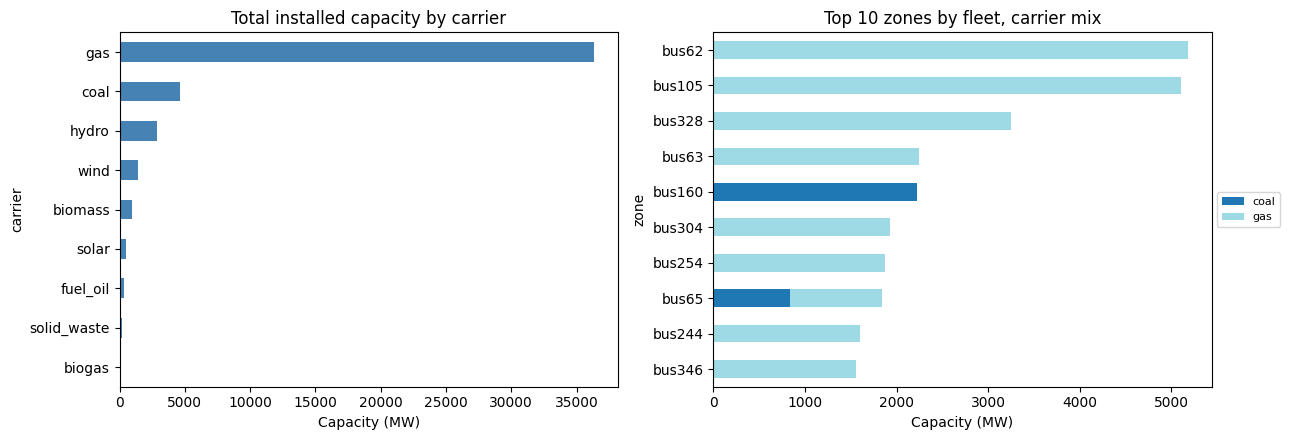

In [11]:
# Aggregate fleet by carrier.
fleet_with_carrier = fleet.merge(
    pd.DataFrame(tech_registry)[['tech', 'carrier']], on='tech'
)
by_carrier = (
    fleet_with_carrier.groupby('carrier')['capacity']
    .sum().sort_values(ascending=False)
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: carrier totals (system-wide).
by_carrier.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_xlabel('Capacity (MW)')
axes[0].set_title('Total installed capacity by carrier')
axes[0].invert_yaxis()

# Right: stacked carrier mix at the top-10 zones by total fleet.
zone_total = fleet.groupby('zone')['capacity'].sum().sort_values(ascending=False)
top10 = zone_total.head(10).index.tolist()
mix = (
    fleet_with_carrier[fleet_with_carrier['zone'].isin(top10)]
    .pivot_table(index='zone', columns='carrier', values='capacity', aggfunc='sum')
    .reindex(top10).fillna(0)
)
mix.plot.barh(stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_xlabel('Capacity (MW)')
axes[1].set_title('Top 10 zones by fleet, carrier mix')
axes[1].invert_yaxis()
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout(); plt.show()


### 6.4 Annual demand profile

System-wide hourly load over 2023 (sum across all 472 buses), with
the peak day highlighted.


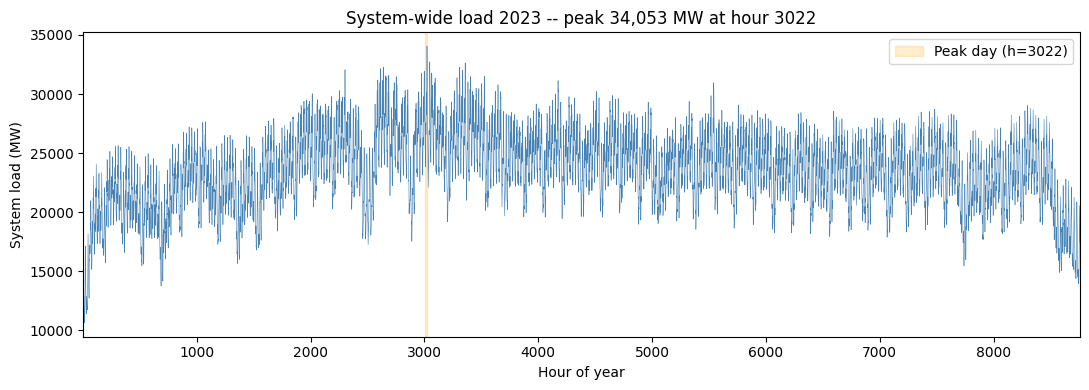

In [12]:
sys_load = long_load.groupby('hour')['value'].sum().sort_index()
peak_h = int(sys_load.idxmax())
peak_day_start = ((peak_h - 1) // 24) * 24 + 1
peak_day_end = peak_day_start + 23

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sys_load.index, sys_load.values, color='steelblue', linewidth=0.4)
ax.axvspan(peak_day_start, peak_day_end, color='orange', alpha=0.2,
           label=f'Peak day (h={peak_h})')
ax.set_xlabel('Hour of year'); ax.set_ylabel('System load (MW)')
ax.set_title(f'System-wide load 2023 -- peak {sys_load.max():,.0f} MW '
             f'at hour {peak_h}')
ax.legend()
ax.set_xlim(1, 8760)
plt.tight_layout(); plt.show()


### 6.5 Resource samples: a VRE plant and a hydro station

Two sample-of-one plots: the hourly capacity factor of one wind
plant over the year, and the hourly natural inflow of one hydro
reservoir.


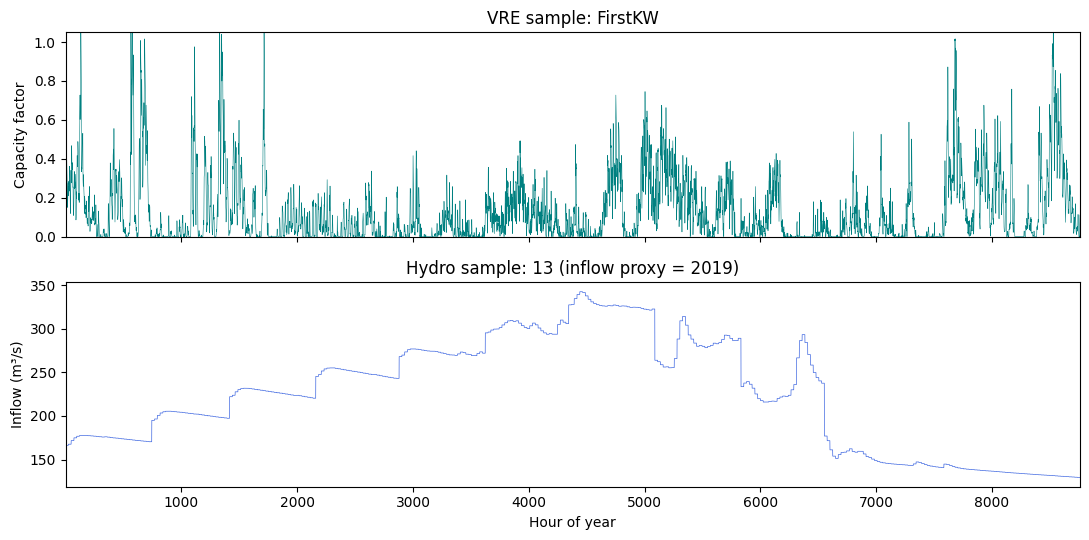

In [13]:
# Pick one wind plant and one hydro station to plot.
sample_wind = next((c for c in cf.columns if c != 'hour' and rt[rt['name']==c]['tech'].iloc[0] == 'wind'), None) if any(rt['tech']=='wind') else cf.columns[1]
sample_hydro = hydro_names[1]  # Bhumibol -- big well-known reservoir

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)

if sample_wind in cf.columns:
    axes[0].plot(cf['hour'], cf[sample_wind], color='teal', linewidth=0.4)
    axes[0].set_ylabel('Capacity factor')
    axes[0].set_title(f'VRE sample: {sample_wind}')
    axes[0].set_ylim(0, 1.05)

inflow_long = pd.DataFrame(inflow_rows)
sample_inf = inflow_long[inflow_long['tech'] == sample_hydro]
axes[1].plot(sample_inf['hour'], sample_inf['value'], color='royalblue', linewidth=0.5)
axes[1].set_xlabel('Hour of year'); axes[1].set_ylabel('Inflow (m³/s)')
axes[1].set_title(f'Hydro sample: {sample_hydro} (inflow proxy = 2019)')

axes[1].set_xlim(1, 8760)
plt.tight_layout(); plt.show()


## 7. Running the PCM rolling-horizon driver

Once the inputs are in place, the canonical invocation is:

```bash
cd examples/thailand_pcm
python -m prepshot.pcm . \
    --year 2023 \
    --horizon 24 --step 24 \
    --cap-source input/capacity_pcm.csv
```

The driver builds a fresh single-day LP for hours 1..24, solves it with the existing fleet locked from `capacity_pcm.csv`, persists the dispatch, advances by 24 h, and repeats — 365 windows for a full year.

Per-window state that flows forward:

- **Hydro reservoir storage** at the terminal hour (clamped just inside `[storage_min, storage_max]` to absorb solver-noise boundary values).
- **Battery SOC**, converted from absolute MWh back to the per-unit-of-cap fraction `initial_energy_storage_level` expects (irrelevant here — no batteries in this dataset).
- **Cross-window cascade outflow**: the upstream's outflow over the lookback period is stashed as a `params['prior_outflow']` numeric lookup so the next window's `hydro.inflow_rule` sees the cascade contribution at boundary hours.


## 8. Knobs to flip on for higher fidelity

All available, all gated by config flags in [config.json](config.json):

| Flag | Effect | Cost |
|------|--------|------|
| `dc_parameters.is_dc_flow: true` | Kirchhoff voltage law on the 615-line network | LP, ~5–10 % build-time bump |
| `dc_parameters.is_n1_secure: true` | Preventive N-1 SCDC OPF; needs lines listed in `transmission_contingencies.csv` | LP, multiplies size by `1 + N_contingencies` |
| `cost_parameters.is_piecewise_heat_rate: true` | Convex piecewise-linear heat rates | LP, modest |
| `uc_parameters.is_uc: true` | Clustered unit commitment | MILP; with 168 thermal units, run rolling-horizon only |
| `reserve_parameters.is_reserve: true` | Multi-product reserves (regulation_up/down, spinning, non_spinning) | LP, modest |

Stack them as your scenario requires. The default config ships with **all of them off** so the first build completes quickly; flip each on once you've confirmed the basic dispatch works.


## 9. Status and caveats

The data conversion shown in this notebook produces a **valid** PREP-SHOT scenario — the loader accepts every CSV and ``initialize_environment`` returns a populated `params` dict.

On the current PREP-SHOT codebase, the LP build itself stalls in PoI's `make_tupledict` Python-level iteration when the model is materialised at this scale (472 zones × 212 techs). For a 24-hour window, ``create_model`` takes 20+ minutes before HiGHS even sees the LP — the bottleneck is constraint construction, not the underlying solver.

Two paths from here:

1. **Aggregate buses** to a smaller zone set before running. Defeats the no-aggregation point, but makes the model tractable today.
2. **Accelerate constraint construction** in `model.py` / `_model/*.py`: Cython, Numba, or batched ``add_linear_constraint`` calls. The right structural fix; would lift PREP-SHOT closer to PowNet / PyPSA scale-handling.

Until either lands, this example is a **data-conversion artefact** — useful as a recipe for plugging an external nodal PCM dataset into PREP-SHOT's input schema.

**Other caveats:**

- Inflow data only covers 2016–2019; we re-use 2019 as the proxy for 2023.
- The 8 import nodes from `import.csv` are not modelled. Add them as fixed-injection rows in `demand.csv` (negative load) if you want them included.
- Source `operation_cost` already bundles fuel + variable O&M. We set `tech_fuel_price=0` and put the whole number in `tech_variable_OM_cost` to avoid double-counting.

**Source attribution.** Input data from the Thai PCM repo at `production-cost-model-main/`. Original developers' attribution applies.
